In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
normalize_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./CIFAR10/train", train=True, transform=normalize_transform, download=True)
test_dataset = torchvision.datasets.CIFAR10(
    root="./CIFAR10/test", train=False, transform=normalize_transform, download=True)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=64, shuffle=False)

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [6]:
# class ConvBlock(nn.Module):

#     def __init__(self, in_channels, out_channels):
#         super().__init__()

#         self.block = nn.Sequential(
#             nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
#             nn.BatchNorm2d(out_channels),
#             nn.ReLU(inplace=True),
#             nn.MaxPool2d(2)
#         )

#     def forward(self, x):
#         return self.block(x)

In [7]:
# class CNN(nn.Module):

#     def __init__(self):
#         super().__init__()

#         # Feature extractor
#         self.features = nn.Sequential(

#             ConvBlock(3, 32),     # 32x32 → 16x16
#             ConvBlock(32, 64),    # 16x16 → 8x8
#             ConvBlock(64, 128)    # 8x8 → 4x4
#         )

#         # Classifier
#         self.classifier = nn.Sequential(

#             nn.Flatten(),

#             nn.Linear(128 * 4 * 4, 256),
#             nn.ReLU(),
#             nn.Dropout(0.5),

#             nn.Linear(256, 10)
#         )

#     def forward(self, x):

#         x = self.features(x)

#         x = self.classifier(x)

#         return x

In [8]:
class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3,32,3,padding=1)
        self.conv2 = nn.Conv2d(32,64,3,padding=1)
        self.conv3 = nn.Conv2d(64,128,3,padding=1)

        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(128*4*4,128)
        self.fc2 = nn.Linear(128,10)

    def forward(self,x):

        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))

        x = x.view(x.size(0),-1)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [9]:
model = CNN().to(device)

print(model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [10]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [28]:
epochs = 20

for epoch in range(epochs):

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.7633
Epoch 2, Loss: 0.6759
Epoch 3, Loss: 0.2519
Epoch 4, Loss: 0.1703
Epoch 5, Loss: 0.1270
Epoch 6, Loss: 0.0809
Epoch 7, Loss: 0.1145
Epoch 8, Loss: 0.0487
Epoch 9, Loss: 0.1959
Epoch 10, Loss: 0.2857
Epoch 11, Loss: 0.2231
Epoch 12, Loss: 0.1432
Epoch 13, Loss: 0.0128
Epoch 14, Loss: 0.0750
Epoch 15, Loss: 0.0741
Epoch 16, Loss: 0.1958
Epoch 17, Loss: 0.3415
Epoch 18, Loss: 0.1232
Epoch 19, Loss: 0.0048
Epoch 20, Loss: 0.2134


In [30]:
model.eval()

with torch.no_grad():

    images, labels = next(iter(test_loader))

    images = images.to(device)

    outputs = model(images)

    _, predicted = torch.max(outputs,1)

In [97]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")


Test Accuracy: 74.38%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..0.9843137].


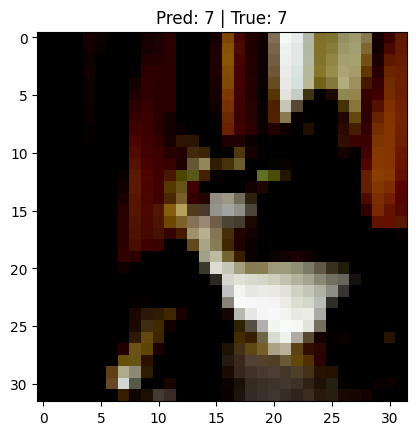

In [ ]:
import matplotlib.pyplot as plt

images1 = images[10].cpu()

if images1.dim() == 3:
    images1 = images1.permute(1, 2, 0)

plt.imshow(images1, cmap="gray" if images1.dim() == 2 else None)
plt.title(f"Pred: {predicted[0].item()} | True: {labels[0].item()}")
plt.show()

In [ ]:
# import matplotlib.pyplot as plt

# images = images[10].cpu()

# if images.dim() == 3:
#     images = images.permute(1, 2, 0)

# plt.imshow(images, cmap="gray" if images.dim() == 2 else None)
# plt.title(f"Pred: {predicted[0].item()} | True: {labels[0].item()}")
# plt.show()

In [96]:
images.shape

torch.Size([3, 32, 32])